## Linear Regression Model Comparison

This script generates synthetic data with outliers and fits six different regression models
to compare their behavior:
- OLS (Ordinary Least Squares)
- LAD (Least Absolute Deviations)
- Huber
- Ridge
- Lasso
- Bayesian

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import (
    LinearRegression,  # OLS
    QuantileRegressor,  # Used for LAD
    HuberRegressor,
    Ridge,
    Lasso,
    BayesianRidge,
)

### Data Generation

In [2]:
np.random.seed(42)

# Generates 50 data points with a linear trend
n_samples = 50
X = np.sort(np.random.rand(n_samples) * 20).reshape(-1, 1)
y_true = 2.5 * X.ravel() + 10  # True linear relationship
y = y_true + np.random.normal(0, 5, n_samples)  # Add Gaussian noise

# Add outliers to test the robustness of the models
n_outliers = 5
outlier_indices = np.random.choice(np.arange(n_samples), n_outliers, replace=False)
y[outlier_indices] = y[outlier_indices] + np.random.uniform(-80, 80, n_outliers)

### Model Definition and Training

In [3]:
models = {
    "OLS": LinearRegression(),
    # LAD (L1 Loss) is equivalent to Quantile Regression on the median (quantile=0.5)
    "LAD (L1 Loss)": QuantileRegressor(quantile=0.5, alpha=0, solver="highs"),
    "Huber": HuberRegressor(),
    # Regularized models (alpha is the regularization parameter)
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.5),
    "Bayesian": BayesianRidge(),
}

# Train each model and store the results
predictions = {}
coefficients = {}

print("Coefficients (Slope) found by each model:")
print("-" * 50)
for name, model in models.items():
    model.fit(X, y)
    predictions[name] = model.predict(X)
    # Stores the slope (slope)
    if hasattr(model, "coef_"):
        coefficients[name] = model.coef_[0]
        print(f"{name:<15}: {model.coef_[0]:.4f}")
print("-" * 50)

Coefficients (Slope) found by each model:
--------------------------------------------------
OLS            : 2.4156
LAD (L1 Loss)  : 2.5163
Huber          : 2.5091
Ridge (L2)     : 2.4142
Lasso (L1)     : 2.4004
Bayesian       : 2.3634
--------------------------------------------------


### Plots

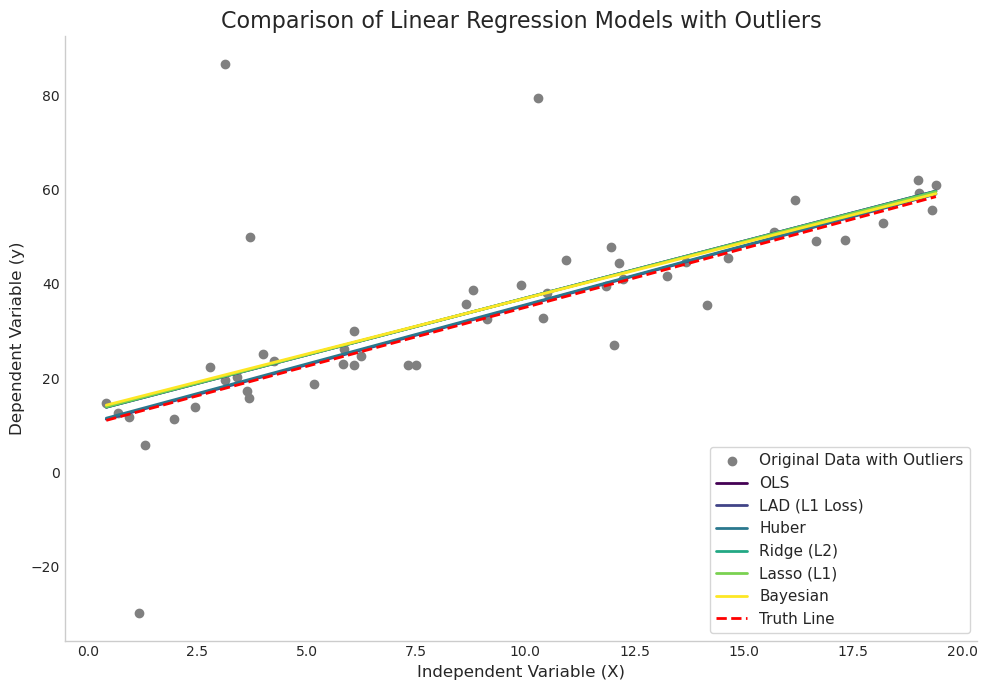

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 7))

# Plot the original data (including outliers)
plt.scatter(X, y, color="gray", marker="o", label="Original Data with Outliers")

# Plot the regression line for each model
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
for i, (name, y_pred) in enumerate(predictions.items()):
    plt.plot(X, y_pred, color=colors[i], linestyle="-", linewidth=2, label=f"{name}")

# Plot the true line (no noise and no outliers) for reference
plt.plot(
    X,
    y_true,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Truth Line",
)

# Chart Settings
plt.title("Comparison of Linear Regression Models with Outliers", fontsize=16)
plt.xlabel("Independent Variable (X)", fontsize=12)
plt.ylabel("Dependent Variable (y)", fontsize=12)
plt.legend(frameon=True, fontsize=11)
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

## Regression Diagnostics

When we talk about regression diagnostics, we are referring to a set of analyses and tests that aim to verify if the assumptions of the regression are being met and if the fitted model is reliable.

In other words: it is not enough to run a linear regression and look only at the R² or the coefficients, we need to evaluate how the residuals and the variables behave, as this reveals problems such as lack of fit, redundant variables, or statistical errors.

### Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.datasets import make_regression

### Data Generation

In [11]:
# We will create a dataset with multicollinearity and heteroscedasticity
np.random.seed(42)
n = 200

X1 = np.random.normal(0, 1, n)
X2 = 2 * X1 + np.random.normal(0, 0.1, n)  # Highly correlated with X1
X3 = np.random.normal(0, 1, n)

# Error variance depends on X3 → heteroscedasticity
error = np.random.normal(0, 1 + 0.5 * np.abs(X3), n)

y = 3 + 2 * X1 - 1.5 * X2 + 0.5 * X3 + error

data = pd.DataFrame({"X1": X1, "X2": X2, "X3": X3, "y": y})
display(data)

,X1,X2,X3,y
0,0.496714,1.029207,-1.594428,3.012874
1,-0.138264,-0.220450,-0.599375,1.555932
2,0.647689,1.403682,0.005244,3.064362
3,1.523030,3.151440,0.046981,2.729872
4,-0.234153,-0.606074,-0.450065,3.722242
...,...,...,...,...
195,0.385317,0.723717,-0.510016,3.751766
196,-0.883857,-1.939028,-0.269875,3.960998
197,0.153725,0.442837,-0.978764,3.168827
198,0.058209,0.104963,-0.444293,2.771435


### Model Definition and Training

In [7]:
X = add_constant(data[["X1", "X2", "X3"]])
model = OLS(data["y"], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     48.78
Date:                Thu, 11 Sep 2025   Prob (F-statistic):           1.36e-23
Time:                        01:08:04   Log-Likelihood:                -348.74
No. Observations:                 200   AIC:                             705.5
Df Residuals:                     196   BIC:                             718.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0449      0.100     30.525      0.0

### Residual Diagnostics

Evaluate if the model's errors (the difference between observed and predicted values) follow the assumptions of the regression:

- Zero mean
- Constant variance (homoscedasticity)
- Approximately normal distribution
- Independence between observations

Problems in the residuals indicate a poor fit or a misspecified model.

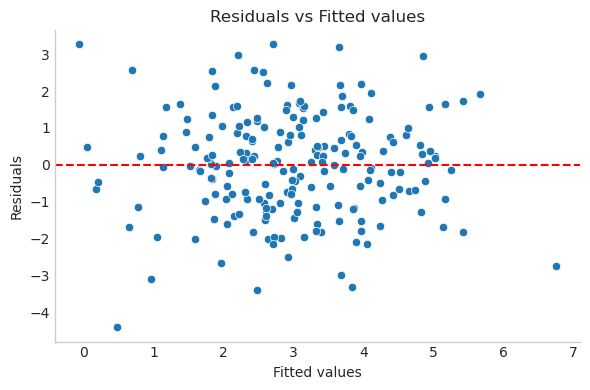

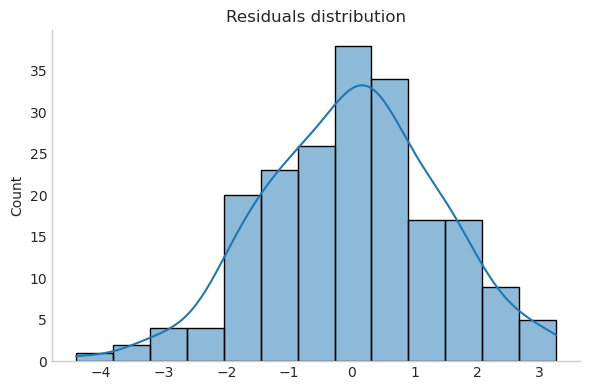

In [15]:
residuals = model.resid
fitted = model.fittedvalues

# Residuals vs Fitted values
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(6, 4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted values")
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

# Histogram of residuals
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

### Multicollinearity (VIF)

It occurs when explanatory variables are highly correlated with each other. This generates instability in the coefficients (small changes in the data can greatly change the parameters). Diagnosis is made by the correlation matrix and by the VIF (Variance Inflation Factor).

In [9]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n=== Variance Inflation Factor (VIF) ===")
print(vif_data)


=== Variance Inflation Factor (VIF) ===
  feature         VIF
0   const    1.018690
1      X1  363.842561
2      X2  363.928506
3      X3    1.018752


### Heteroscedasticity Test

When the variance of the residuals is not constant (e.g., it increases as the value of Y grows). It affects the validity of statistical tests (p-values, confidence intervals). It can be diagnosed by residual plots and by tests like Breusch-Pagan.

In [10]:
bp_test = het_breuschpagan(residuals, X)
labels = ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"]
print("\n=== Breusch-Pagan Test ===")
print(dict(zip(labels, bp_test)))


=== Breusch-Pagan Test ===
{'LM Statistic': np.float64(6.78159335820272), 'LM-Test p-value': np.float64(0.07919472869597853), 'F-Statistic': np.float64(2.293073973143582), 'F-Test p-value': np.float64(0.07930610624492955)}
